In [1]:
import parselmouth
import glob
import os


In [2]:
from parselmouth.praat import call

In [3]:
#!pip install praat-parselmouth

In [4]:
!pip install tqdm

In [5]:
tg_dir = r"D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2"


In [6]:
tg_files = glob.glob(os.path.join(tg_dir, '*.TextGrid'))
print(f'Найдено файлов: {len(tg_files)}')

Найдено файлов: 22199


In [7]:
tg_path = tg_files[0]
tg = parselmouth.read(tg_path)
print(f"Тип объекта: {type(tg)}")
num_tiers = call(tg, "Get number of tiers")
print(f"Количество уровней: {num_tiers}")

Тип объекта: <class 'parselmouth.TextGrid'>
Количество уровней: 2


In [8]:
for i in range(1, num_tiers + 1):
    tier_name = call(tg, "Get tier name", i)
    num_intervals = call(tg, "Get number of intervals", i)

    print(f"Уровень: '{tier_name}' (всего интервалов: {num_intervals})")

    for j in range(1, min(11, num_intervals +1)):
        label = call(tg, "Get label of interval", i, j)
        start = call(tg, "Get start time of interval", i, j)
        end = call(tg, "Get end time of interval", i, j)
        duration = end - start
        print(f" [{j}] '{label}' | {start:.3f} - {end:.3f} | duration: {duration:.3f} sec")

Уровень: 'words' (всего интервалов: 8)
 [1] 'с' | 0.000 - 0.110 | duration: 0.110 sec
 [2] 'тревожным' | 0.110 - 0.690 | duration: 0.580 sec
 [3] 'чувством' | 0.690 - 1.310 | duration: 0.620 sec
 [4] 'берусь' | 1.310 - 1.700 | duration: 0.390 sec
 [5] 'я' | 1.700 - 1.790 | duration: 0.090 sec
 [6] 'за' | 1.790 - 1.920 | duration: 0.130 sec
 [7] 'перо' | 1.920 - 2.210 | duration: 0.290 sec
 [8] '' | 2.210 - 2.245 | duration: 0.035 sec
Уровень: 'phones' (всего интервалов: 31)
 [1] 's̪' | 0.000 - 0.110 | duration: 0.110 sec
 [2] 't̪' | 0.110 - 0.180 | duration: 0.070 sec
 [3] 'rʲ' | 0.180 - 0.260 | duration: 0.080 sec
 [4] 'ɪ' | 0.260 - 0.270 | duration: 0.010 sec
 [5] 'v' | 0.270 - 0.360 | duration: 0.090 sec
 [6] 'o' | 0.360 - 0.470 | duration: 0.110 sec
 [7] 'ʐ' | 0.470 - 0.570 | duration: 0.100 sec
 [8] 'n̪' | 0.570 - 0.610 | duration: 0.040 sec
 [9] 'ɨ' | 0.610 - 0.640 | duration: 0.030 sec
 [10] 'm' | 0.640 - 0.690 | duration: 0.050 sec


Сбор Статистики по датасету

In [9]:
import pandas as pd
from tqdm import tqdm
import glob
import os
import parselmouth
from parselmouth.praat import call

In [10]:
tg_dir = r"D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2"
tg_files = glob.glob(os.path.join(tg_dir, "*.TextGrid"))

In [11]:
words_data = []
phones_data = []
pauses_data = []

for tg_path in tqdm(tg_files, desc="Обработка файлов"):
    try:
        tg = parselmouth.read(tg_path)
        filename = os.path.basename(tg_path).replace(".TextGrid", "")
        
        num_tiers = call(tg, "Get number of tiers")
        
        for i in range(1, num_tiers + 1):
            tier_name = call(tg, "Get tier name", i)
            num_intervals = call(tg, "Get number of intervals", i)
            
            for j in range(1, num_intervals + 1):
                label = call(tg, "Get label of interval", i, j)
                start = call(tg, "Get start time of interval", i, j)
                end = call(tg, "Get end time of interval", i, j)
                duration = end - start
                
                row = {
                    "file": filename,
                    "label": label.strip(),
                    "start": start,
                    "end": end,
                    "duration": duration
                }
                
                if tier_name == "words":
                    words_data.append(row)
                    if label.strip() == "":
                        pauses_data.append(row)
                elif tier_name == "phones":
                    phones_data.append(row)
    
    except Exception as e:
        print(e)
        pass  # пропускаем ошибки

# Создаем DataFrame
df_words = pd.DataFrame(words_data)
df_phones = pd.DataFrame(phones_data)
df_pauses = pd.DataFrame(pauses_data)

print(f"\n✅ Готово!")
print(f"Слов: {len(df_words)}")
print(f"Фонем: {len(df_phones)}")
print(f"Пауз: {len(df_pauses)}")

# Сохраняем 
df_words.to_csv("words_data.csv", index=False)
df_phones.to_csv("phones_data.csv", index=False)
df_pauses.to_csv("pauses_data.csv", index=False)
print("\n💾 Данные сохранены в CSV файлы")

Обработка файлов: 100%|██████████| 22199/22199 [14:31<00:00, 25.46it/s]



✅ Готово!
Слов: 317878
Фонем: 1488456
Пауз: 62431

💾 Данные сохранены в CSV файлы


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:

df_words = pd.read_csv("words_data.csv")
df_phones = pd.read_csv("phones_data.csv")
df_pauses = pd.read_csv("pauses_data.csv")

print("\n📝 СЛОВА:")
print(f"  Всего слов: {len(df_words)}")
print(f"  Средняя длительность слова: {df_words['duration'].mean():.4f} сек")
print(f"  Медианная длительность: {df_words['duration'].median():.4f} сек")
print(f"  Минимальная: {df_words['duration'].min():.4f} сек")
print(f"  Максимальная: {df_words['duration'].max():.4f} сек")
print(f"  Стандартное отклонение: {df_words['duration'].std():.4f} сек")

print("\n🔤 ФОНЕМЫ:")
print(f"  Всего фонем: {len(df_phones)}")
print(f"  Средняя длительность фонемы: {df_phones['duration'].mean():.4f} сек")
print(f"  Медианная длительность: {df_phones['duration'].median():.4f} сек")
print(f"  Минимальная: {df_phones['duration'].min():.4f} сек")
print(f"  Максимальная: {df_phones['duration'].max():.4f} сек")

print("\n⏸️ ПАУЗЫ:")
print(f"  Всего пауз: {len(df_pauses)}")
if len(df_pauses) > 0:
    print(f"  Средняя длительность паузы: {df_pauses['duration'].mean():.4f} сек")
    print(f"  Медианная длительность: {df_pauses['duration'].median():.4f} сек")
    print(f"  Минимальная: {df_pauses['duration'].min():.4f} сек")
    print(f"  Максимальная: {df_pauses['duration'].max():.4f} сек")

vowels_ipa = ['a', 'e', 'i', 'o', 'u', 'ɨ', 'ɪ', 'ə', 'ɐ', 'ɵ', 'ʉ', 'ɘ', 'ɜ', 'æ', 'ɑ', 'ɔ', 'ʊ', 'ɛ', 'y', 'ø']
df_phones['is_vowel'] = df_phones['label'].apply(lambda x: any(v in str(x).lower() for v in vowels_ipa))
df_vowels = df_phones[df_phones['is_vowel']]

print("\n🔵 ГЛАСНЫЕ:")
print(f"  Всего гласных: {len(df_vowels)}")
if len(df_vowels) > 0:
    print(f"  Средняя длительность гласной: {df_vowels['duration'].mean():.4f} сек")
    print(f"  Медианная длительность: {df_vowels['duration'].median():.4f} сек")
    print(f"  Минимальная: {df_vowels['duration'].min():.4f} сек")
    print(f"  Максимальная: {df_vowels['duration'].max():.4f} сек")


📝 СЛОВА:
  Всего слов: 317878
  Средняя длительность слова: 0.3573 сек
  Медианная длительность: 0.3500 сек
  Минимальная: 0.0100 сек
  Максимальная: 15.1150 сек
  Стандартное отклонение: 0.2412 сек

🔤 ФОНЕМЫ:
  Всего фонем: 1488456
  Средняя длительность фонемы: 0.0763 сек
  Медианная длительность: 0.0700 сек
  Минимальная: 0.0049 сек
  Максимальная: 15.1150 сек

⏸️ ПАУЗЫ:
  Всего пауз: 62431
  Средняя длительность паузы: 0.1393 сек
  Медианная длительность: 0.0700 сек
  Минимальная: 0.0249 сек
  Максимальная: 15.1150 сек

🔵 ГЛАСНЫЕ:
  Всего гласных: 666702
  Средняя длительность гласной: 0.0643 сек
  Медианная длительность: 0.0500 сек
  Минимальная: 0.0049 сек
  Максимальная: 15.1150 сек


Категория /	Нормальная длительность /	Что считаем аномалией
Слова	0.01 – 2.0 сек	> 2 сек (это уже фраза, а не слово)
Фонемы	0.01 – 1.0 сек	> 1 сек (фонема не может длиться секунду)
Гласные	0.01 – 0.5 сек	> 0.5 сек (гласная короткая)
Паузы	0.01 – 5.0 сек	> 5 сек (слишком длинная пауза — ошибка)

Слово — это может быть длинное слово типа "послереволюционной" (4 сек — многовато, но возможно). Поэтому порог 2 сек.

Фонема — это один звук. Даже самый долгий звук не длится больше 1 секунды. Порог 1 сек.

Гласная — это звук, который длится в среднем 0.05–0.3 сек. Порог 0.5 сек.

Пауза — может быть длинной (пауза между предложениями), но > 5 сек — это уже ошибка разметки. Порог 5 сек.

In [14]:
df_words[df_words['duration'] > 3]

,file,label,start,end,duration
50386,006229_RUSLAN,[bracketed],2.43,5.760000,3.330000
57850,006695_RUSLAN,NaN,6.19,13.284898,7.094898
60343,006863_RUSLAN,уборной,0.29,5.050000,4.760000
77244,007998_RUSLAN,NaN,1.33,5.519637,4.189637
106821,010010_RUSLAN,[bracketed],0.14,5.430431,5.290431
116564,010686_RUSLAN,NaN,0.93,7.990249,7.060249
125183,011267_RUSLAN,потрепанной,2.98,7.190000,4.210000
136353,011939_RUSLAN,[bracketed],0.37,3.860000,3.490000
150826,012854_RUSLAN,[bracketed],0.00,4.350000,4.350000
150929,012862_RUSLAN,[bracketed],0.15,4.719546,4.569546


In [15]:


# 1. СЛОВА
df_words = pd.read_csv("words_data.csv")
df_words_clean = df_words[
    (df_words['duration'] < 2.0) &
    (df_words['label'].notna()) &
    (df_words['label'] != '[bracketed]') &
    (df_words['label'].str.strip() != '')
].copy()
print(f"\n📝 СЛОВА:")
print(f"  Было: {len(df_words)}")
print(f"  Стало: {len(df_words_clean)}")
print(f"  Удалено: {len(df_words) - len(df_words_clean)}")

# 2. ФОНЕМЫ
df_phones = pd.read_csv("phones_data.csv")
df_phones_clean = df_phones[
    (df_phones['duration'] < 1.0) &
    (df_phones['label'].notna()) &
    (df_phones['label'].str.strip() != '') &
    (df_phones['label'] != '[bracketed]')
].copy()
print(f"\n🔤 ФОНЕМЫ:")
print(f"  Было: {len(df_phones)}")
print(f"  Стало: {len(df_phones_clean)}")
print(f"  Удалено: {len(df_phones) - len(df_phones_clean)}")

# 3. ГЛАСНЫЕ (из очищенных фонем)
vowels_ipa = ['a', 'e', 'i', 'o', 'u', 'ɨ', 'ɪ', 'ə', 'ɐ', 'ɵ', 'ʉ', 'ɘ', 'ɜ', 'æ', 'ɑ', 'ɔ', 'ʊ', 'ɛ', 'y', 'ø']
df_phones_clean['is_vowel'] = df_phones_clean['label'].apply(
    lambda x: any(v in str(x).lower() for v in vowels_ipa)
)
df_vowels_clean = df_phones_clean[df_phones_clean['is_vowel']].copy()
df_consonants_clean = df_phones_clean[~df_phones_clean['is_vowel']].copy()

print(f"\n🔵 ГЛАСНЫЕ:")
print(f"  Всего: {len(df_vowels_clean)}")
print(f"  Средняя длительность: {df_vowels_clean['duration'].mean():.4f} сек")

print(f"\n🔴 СОГЛАСНЫЕ:")
print(f"  Всего: {len(df_consonants_clean)}")
print(f"  Средняя длительность: {df_consonants_clean['duration'].mean():.4f} сек")

# 4. ПАУЗЫ
df_pauses = pd.read_csv("pauses_data.csv")
df_pauses_clean = df_pauses[
    (df_pauses['duration'] < 5.0) &
    (df_pauses['duration'] > 0.0)
].copy()
print(f"\n⏸️ ПАУЗЫ:")
print(f"  Было: {len(df_pauses)}")
print(f"  Стало: {len(df_pauses_clean)}")
print(f"  Удалено: {len(df_pauses) - len(df_pauses_clean)}")
print(f"  Средняя длительность: {df_pauses_clean['duration'].mean():.4f} сек")

# Сохраняем очищенные данные
df_words_clean.to_csv("words_clean.csv", index=False)
df_phones_clean.to_csv("phones_clean.csv", index=False)
df_vowels_clean.to_csv("vowels_clean.csv", index=False)
df_consonants_clean.to_csv("consonants_clean.csv", index=False)
df_pauses_clean.to_csv("pauses_clean.csv", index=False)

print("\n💾 Все очищенные данные сохранены в CSV")


📝 СЛОВА:
  Было: 317878
  Стало: 255106
  Удалено: 62772

🔤 ФОНЕМЫ:
  Было: 1488456
  Стало: 1425732
  Удалено: 62724

🔵 ГЛАСНЫЕ:
  Всего: 604154
  Средняя длительность: 0.0562 сек

🔴 СОГЛАСНЫЕ:
  Всего: 821578
  Средняя длительность: 0.0857 сек

⏸️ ПАУЗЫ:
  Было: 62431
  Стало: 62427
  Удалено: 4
  Средняя длительность: 0.1388 сек

💾 Все очищенные данные сохранены в CSV


Согласные длиннее гласных (0.0857 vs 0.0562 сек) — это необычно! Обычно гласные длиннее. Возможно, в корпусе много долгих согласных (например, аффрикат) или это особенность разметки.

Паузы очень короткие (0.1388 сек) — средняя пауза всего 139 мс. Это короткие паузы между словами, а не между предложениями.

Гласных меньше, чем согласных (604k vs 821k) — это нормально для русского языка, где согласных больше.

Слов 255k, фонем 1 425k — в среднем 5.6 фонем на слово. Это нормально для русского.

In [16]:
df_phones_clean = pd.read_csv("phones_clean.csv")

print("🔤 СТАТИСТИКА ПО ФОНЕМАМ")

print(f"Всего фонем: {len(df_phones_clean)}")
print(f"Средняя длительность фонемы: {df_phones_clean['duration'].mean():.4f} сек")
print(f"Медиана: {df_phones_clean['duration'].median():.4f} сек")
print(f"Минимум: {df_phones_clean['duration'].min():.4f} сек")
print(f"Максимум: {df_phones_clean['duration'].max():.4f} сек")

# Топ-20 самых частых фонем
print(f"\n📌 Топ-20 самых частых фонем:")
print(df_phones_clean['label'].value_counts().head(20))

🔤 СТАТИСТИКА ПО ФОНЕМАМ
Всего фонем: 1425732
Средняя длительность фонемы: 0.0732 сек
Медиана: 0.0700 сек
Минимум: 0.0049 сек
Максимум: 0.9966 сек

📌 Топ-20 самых частых фонем:
label
ɪ     115401
ə     108045
ɐ      74937
a      63780
t̪     62173
j      55664
n̪     51120
e      49893
r      45767
s̪     45418
ɨ      43571
o      42528
i      42471
v      41983
k      39150
ɫ      36846
m      33690
ʎ      32855
ɲ      30473
p      29499
Name: count, dtype: int64


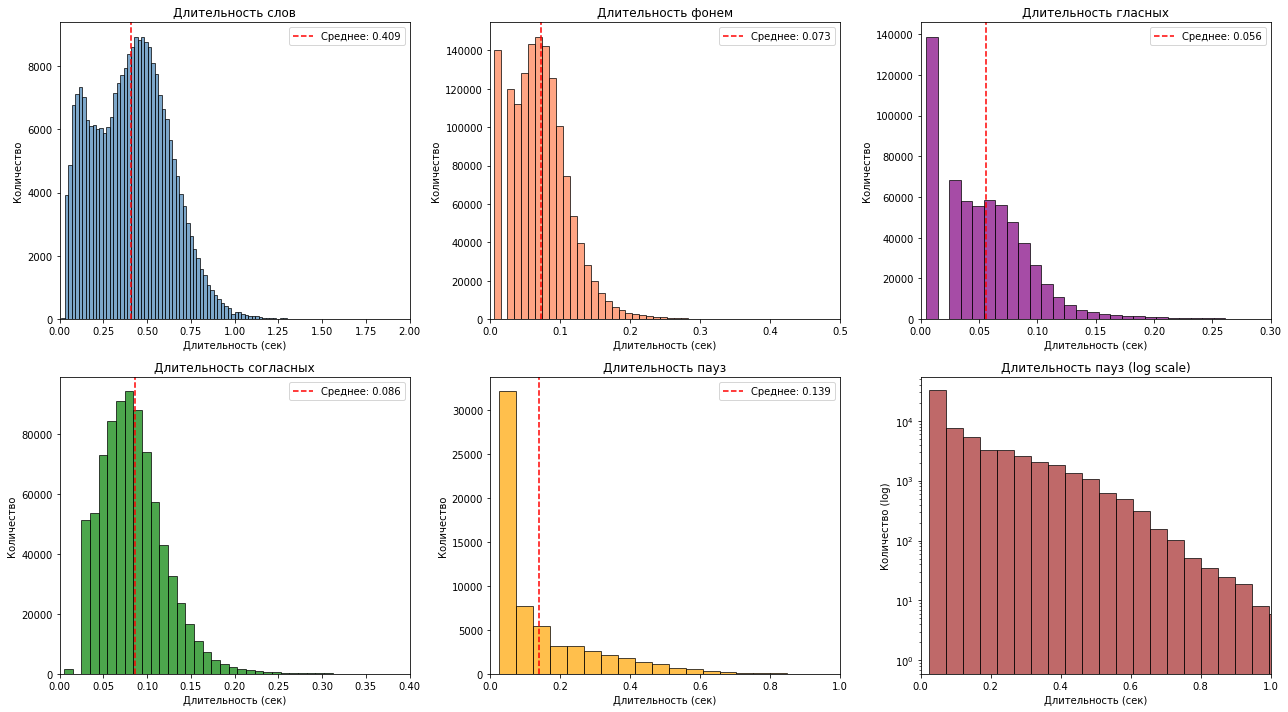

✅ Гистограмма сохранена в 'duration_distributions.png'


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Слова
axes[0, 0].hist(df_words_clean['duration'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Длительность слов')
axes[0, 0].set_xlabel('Длительность (сек)')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].axvline(df_words_clean['duration'].mean(), color='red', linestyle='--', 
                   label=f'Среднее: {df_words_clean["duration"].mean():.3f}')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 2)

# 2. Фонемы
axes[0, 1].hist(df_phones_clean['duration'], bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Длительность фонем')
axes[0, 1].set_xlabel('Длительность (сек)')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].axvline(df_phones_clean['duration'].mean(), color='red', linestyle='--',
                   label=f'Среднее: {df_phones_clean["duration"].mean():.3f}')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 0.5)

# 3. Гласные
axes[0, 2].hist(df_vowels_clean['duration'], bins=100, color='purple', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Длительность гласных')
axes[0, 2].set_xlabel('Длительность (сек)')
axes[0, 2].set_ylabel('Количество')
axes[0, 2].axvline(df_vowels_clean['duration'].mean(), color='red', linestyle='--',
                   label=f'Среднее: {df_vowels_clean["duration"].mean():.3f}')
axes[0, 2].legend()
axes[0, 2].set_xlim(0, 0.3)

# 4. Согласные
axes[1, 0].hist(df_consonants_clean['duration'], bins=100, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Длительность согласных')
axes[1, 0].set_xlabel('Длительность (сек)')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].axvline(df_consonants_clean['duration'].mean(), color='red', linestyle='--',
                   label=f'Среднее: {df_consonants_clean["duration"].mean():.3f}')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 0.4)

# 5. Паузы
axes[1, 1].hist(df_pauses_clean['duration'], bins=100, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Длительность пауз')
axes[1, 1].set_xlabel('Длительность (сек)')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].axvline(df_pauses_clean['duration'].mean(), color='red', linestyle='--',
                   label=f'Среднее: {df_pauses_clean["duration"].mean():.3f}')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 1)

# 6. Логарифмическая шкала для пауз
axes[1, 2].hist(df_pauses_clean['duration'], bins=100, color='brown', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Длительность пауз (log scale)')
axes[1, 2].set_xlabel('Длительность (сек)')
axes[1, 2].set_ylabel('Количество (log)')
axes[1, 2].set_yscale('log')
axes[1, 2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('duration_distributions.png', dpi=150)
plt.show()
print("✅ Гистограмма сохранена в 'duration_distributions.png'")

⏸️ КЛАССИФИКАЦИЯ ПАУЗ ПО ДЛИТЕЛЬНОСТИ

📊 Статистика пауз:
  Всего пауз: 62427
  Средняя: 0.1388 сек
  Медиана: 0.0700 сек
  Минимум: 0.0249 сек
  Максимум: 4.8758 сек

📊 Процентили:
  10%: 0.0300 сек
  25%: 0.0300 сек
  50%: 0.0700 сек
  75%: 0.1900 сек
  90%: 0.3600 сек
  95%: 0.4600 сек
  99%: 0.6200 сек


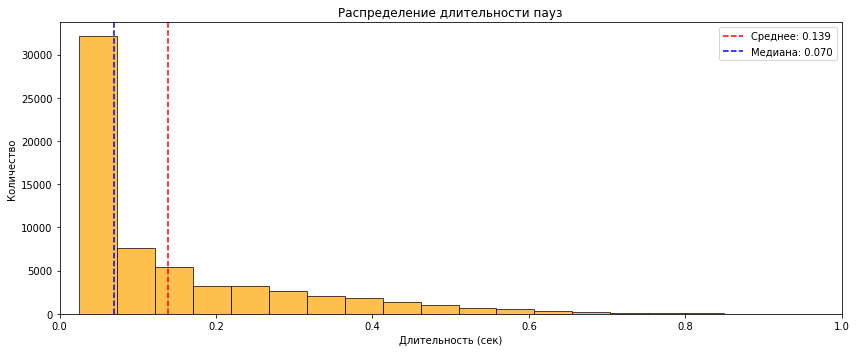

In [18]:
df_pauses_clean = pd.read_csv("pauses_clean.csv")


print("⏸️ КЛАССИФИКАЦИЯ ПАУЗ ПО ДЛИТЕЛЬНОСТИ")


# Смотрим на распределение
print(f"\n📊 Статистика пауз:")
print(f"  Всего пауз: {len(df_pauses_clean)}")
print(f"  Средняя: {df_pauses_clean['duration'].mean():.4f} сек")
print(f"  Медиана: {df_pauses_clean['duration'].median():.4f} сек")
print(f"  Минимум: {df_pauses_clean['duration'].min():.4f} сек")
print(f"  Максимум: {df_pauses_clean['duration'].max():.4f} сек")

# Процентили
print(f"\n📊 Процентили:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_pauses_clean['duration'], p)
    print(f"  {p}%: {val:.4f} сек")

# Гистограмма
plt.figure(figsize=(12, 5))
plt.hist(df_pauses_clean['duration'], bins=100, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(df_pauses_clean['duration'].mean(), color='red', linestyle='--', label=f'Среднее: {df_pauses_clean["duration"].mean():.3f}')
plt.axvline(df_pauses_clean['duration'].median(), color='blue', linestyle='--', label=f'Медиана: {df_pauses_clean["duration"].median():.3f}')
plt.title('Распределение длительности пауз')
plt.xlabel('Длительность (сек)')
plt.ylabel('Количество')
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


📊 КЛАССЫ ПАУЗ ПО ДЛИТЕЛЬНОСТИ

📊 Распределение пауз по классам:
  Сверхкороткая (< 50 мс)         26882 ( 43.1%) █████████████████████
  Короткая (50-100 мс)             9338 ( 15.0%) ███████
  Средняя (100-200 мс)            10961 ( 17.6%) ████████
  Длинная (200-500 мс)            12972 ( 20.8%) ██████████
  Очень длинная (500-1000 мс)      2204 (  3.5%) █
  Сверхдлинная (> 1 сек)             70 (  0.1%) 


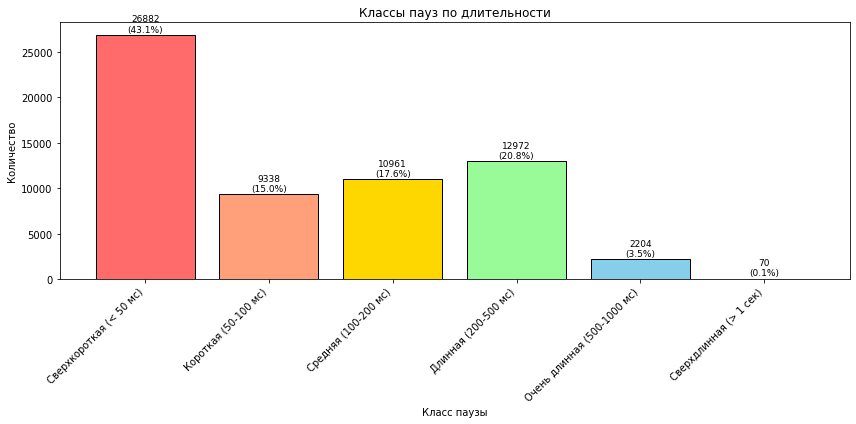

In [19]:
print("\n" + "=" * 80)
print("📊 КЛАССЫ ПАУЗ ПО ДЛИТЕЛЬНОСТИ")
print("=" * 80)

def classify_pause(duration):
    if duration < 0.05:
        return "Сверхкороткая (< 50 мс)"
    elif duration < 0.1:
        return "Короткая (50-100 мс)"
    elif duration < 0.2:
        return "Средняя (100-200 мс)"
    elif duration < 0.5:
        return "Длинная (200-500 мс)"
    elif duration < 1.0:
        return "Очень длинная (500-1000 мс)"
    else:
        return "Сверхдлинная (> 1 сек)"

df_pauses_clean['pause_class'] = df_pauses_clean['duration'].apply(classify_pause)

# Считаем по классам
class_counts = df_pauses_clean['pause_class'].value_counts()
class_order = [
    "Сверхкороткая (< 50 мс)",
    "Короткая (50-100 мс)",
    "Средняя (100-200 мс)",
    "Длинная (200-500 мс)",
    "Очень длинная (500-1000 мс)",
    "Сверхдлинная (> 1 сек)"
]

print("\n📊 Распределение пауз по классам:")
for cls in class_order:
    count = class_counts.get(cls, 0)
    pct = count / len(df_pauses_clean) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls:30} {count:>6} ({pct:>5.1f}%) {bar}")

# Визуализация
plt.figure(figsize=(12, 6))
class_counts_ordered = [class_counts.get(cls, 0) for cls in class_order]
colors = ['#FF6B6B', '#FFA07A', '#FFD700', '#98FB98', '#87CEEB', '#9370DB']
bars = plt.bar(class_order, class_counts_ordered, color=colors, edgecolor='black')
plt.title('Классы пауз по длительности')
plt.xlabel('Класс паузы')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')

# Добавляем значения на график
for bar, count in zip(bars, class_counts_ordered):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{count}\n({count/len(df_pauses_clean)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('pause_classes.png', dpi=150)
plt.show()

In [20]:

print("📍 ГДЕ ПОЯВЛЯЮТСЯ ПАУЗЫ?")

# Загружаем данные слов для анализа контекста
df_words_clean = pd.read_csv("words_clean.csv")

# Анализируем позицию паузы в файле
# Для каждой паузы смотрим:
# 1. Это начало файла? (start == 0)
# 2. Это конец файла? (end == максимальное время)
# 3. Это середина?

pause_positions = []

for idx, pause in df_pauses_clean.iterrows():
    file_name = pause['file']
    start = pause['start']
    end = pause['end']
    
    # Находим все слова в этом файле
    file_words = df_words_clean[df_words_clean['file'] == file_name]
    
    if len(file_words) == 0:
        continue
    
    max_time = file_words['end'].max()
    min_time = file_words['start'].min()
    
    # Определяем позицию
    if start <= min_time + 0.01:
        position = "В начале"
    elif end >= max_time - 0.01:
        position = "В конце"
    else:
        position = "В середине"
    
    pause_positions.append({
        'file': file_name,
        'duration': pause['duration'],
        'position': position,
        'start': start,
        'end': end
    })

df_positions = pd.DataFrame(pause_positions)

if len(df_positions) > 0:
    pos_counts = df_positions['position'].value_counts()
    print("\n📊 Распределение пауз по позиции:")
    for pos, count in pos_counts.items():
        pct = count / len(df_positions) * 100
        print(f"  {pos}: {count} ({pct:.1f}%)")
    
    # Средняя длительность по позициям
    print("\n📊 Средняя длительность паузы по позиции:")
    for pos in pos_counts.index:
        avg_dur = df_positions[df_positions['position'] == pos]['duration'].mean()
        print(f"  {pos}: {avg_dur:.4f} сек")

📍 ГДЕ ПОЯВЛЯЮТСЯ ПАУЗЫ?

📊 Распределение пауз по позиции:
  В середине: 49028 (78.6%)
  В конце: 12391 (19.9%)
  В начале: 996 (1.6%)

📊 Средняя длительность паузы по позиции:
  В середине: 0.1627 сек
  В конце: 0.0494 сек
  В начале: 0.0568 сек


КЛАССЫ ПАУЗ ПО ПОЗИЦИИ И ДЛИТЕЛЬНОСТИ

📊 Кросс-таблица (позиция × класс):
pause_class  Длинная (200-500 мс)  Короткая (50-100 мс)  \
position                                                  
В конце                       162                   744   
В начале                       43                    60   
В середине                  12767                  8534   

pause_class  Очень длинная (500-1000 мс)  Сверхдлинная (> 1 сек)  \
position                                                           
В конце                               42                      36   
В начале                               4                       0   
В середине                          2158                      27   

pause_class  Сверхкороткая (< 50 мс)  Средняя (100-200 мс)  
position                                                    
В конце                        10836                   571  
В начале                         796                    93  
В середине                     15249         

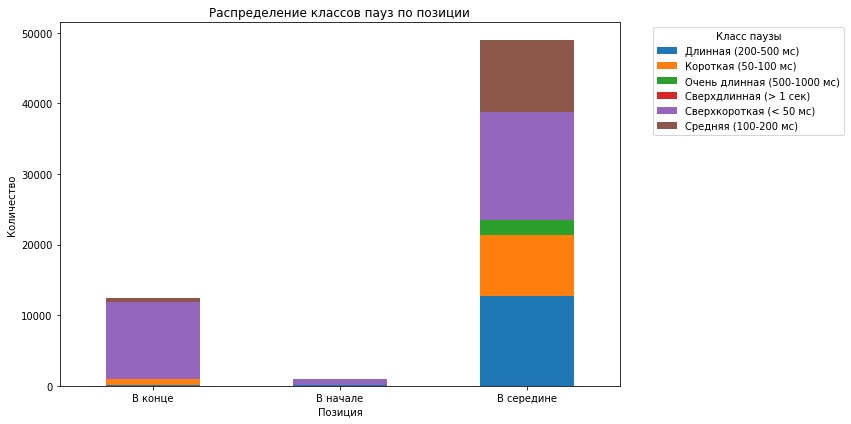

In [21]:
print("КЛАССЫ ПАУЗ ПО ПОЗИЦИИ И ДЛИТЕЛЬНОСТИ")


if len(df_positions) > 0:
    # Кросс-таблица: позиция × класс
    df_positions['pause_class'] = df_positions['duration'].apply(classify_pause)
    
    cross_tab = pd.crosstab(df_positions['position'], df_positions['pause_class'])
    print("\n📊 Кросс-таблица (позиция × класс):")
    print(cross_tab)
    
    # Визуализация
    cross_tab.plot(kind='bar', figsize=(12, 6), stacked=True)
    plt.title('Распределение классов пауз по позиции')
    plt.xlabel('Позиция')
    plt.ylabel('Количество')
    plt.xticks(rotation=0)
    plt.legend(title='Класс паузы', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('pause_position_classes.png', dpi=150)
    plt.show()

In [22]:
print("АНАЛИЗ ЛОГИЧНОСТИ ПАУЗ")

if len(df_positions) > 0:
    # Логичные паузы: в конце предложения или между предложениями
    # Нелогичные: в середине слова (если такие есть)
    
    # Проверяем паузы в середине
    middle_pauses = df_positions[df_positions['position'] == "В середине"]
    
    print(f"\n📍 Паузы в середине: {len(middle_pauses)} ({len(middle_pauses)/len(df_positions)*100:.1f}%)")
    
    # Смотрим на длительность пауз в середине
    if len(middle_pauses) > 0:
        print(f"  Средняя длительность: {middle_pauses['duration'].mean():.4f} сек")
        print(f"  Медиана: {middle_pauses['duration'].median():.4f} сек")
        
        # Короткие паузы в середине — это нормально (между словами)
        # Длинные паузы в середине — подозрительно
        long_middle = middle_pauses[middle_pauses['duration'] > 0.5]
        print(f"\n  ⚠️ Длинных пауз в середине (> 0.5 сек): {len(long_middle)}")
        
        if len(long_middle) > 0:
            print(f"  Примеры:")
            for idx, row in long_middle.head(10).iterrows():
                print(f"    {row['file']}: {row['duration']:.3f} сек (позиция {row['start']:.2f}-{row['end']:.2f})")

АНАЛИЗ ЛОГИЧНОСТИ ПАУЗ

📍 Паузы в середине: 49028 (78.6%)
  Средняя длительность: 0.1627 сек
  Медиана: 0.1000 сек

  ⚠️ Длинных пауз в середине (> 0.5 сек): 2002
  Примеры:
    000116_RUSLAN: 0.920 сек (позиция 3.78-4.70)
    000145_RUSLAN: 0.550 сек (позиция 0.64-1.19)
    000206_RUSLAN: 0.770 сек (позиция 4.09-4.86)
    000213_RUSLAN: 0.600 сек (позиция 1.84-2.44)
    000239_RUSLAN: 0.500 сек (позиция 1.97-2.47)
    000256_RUSLAN: 0.590 сек (позиция 3.28-3.87)
    000354_RUSLAN: 0.750 сек (позиция 3.01-3.76)
    000391_RUSLAN: 0.580 сек (позиция 2.30-2.88)
    002129_RUSLAN: 0.530 сек (позиция 4.27-4.80)
    002155_RUSLAN: 0.530 сек (позиция 4.12-4.65)


В конце (12 391 пауза)

Класс /	Кол-во / Доля
Сверхкороткая (< 50 мс)	10 836	87.5%
Короткая (50–100 мс)	744	6.0%
Средняя (100–200 мс)	571	4.6%
Длинная (200–500 мс)	162	1.3%
Очень длинная (500–1000 мс)	42	0.3%
Сверхдлинная (> 1 сек)	36	0.3%

87.5% «пауз в конце» короче 50 мс! Это не паузы, это микро-разрывы в разметке. Настоящая пауза в конце предложения — это 300+ мс.

In [ ]:
В начале (996 пауза)

Класс /	Кол-во /	Доля
Сверхкороткая (< 50 мс)	796	79.9%
Короткая (50–100 мс)	60	6.0%
Средняя (100–200 мс)	93	9.3%
Длинная (200–500 мс)	43	4.3%
Очень длинная	4	0.4%
Сверхдлинная	0	0%
Та же картина: 80% — микро-разрывы.

In [ ]:
В середине (49 028 пауз)

Класс /	Кол-во / Доля
Сверхкороткая (< 50 мс)	15 249	31.1%
Короткая (50–100 мс)	8 534	17.4%
Средняя (100–200 мс)	10 293	21.0%
Длинная (200–500 мс)	12 767	26.0%
Очень длинная (500–1000 мс)	2 158	4.4%
Сверхдлинная (> 1 сек)	27	0.06%
✅ В середине распределение гораздо здоровее! Здесь есть все классы, и 30% — это паузы > 200 мс. Это уже похоже на настоящие межсловные паузы.

Позиция /	Медиана /	Доля < 50 мс
В середине	100 мс	31%
В конце	~30 мс	87.5%
В начале	~30 мс	80%
Что это значит?

«Паузы в конце» и «в начале» — это не паузы, а артефакты автоматической разметки:

TextGrid иногда вставляет пустой интервал в начало/конец файла

Это технический «хвост» или «голова» записи

Длительность 20–50 мс — это просто зазор между границами

Настоящие паузы живут в середине — там, где между словами реально есть перерыв.

In [28]:
pause_contexts = []

for tg_path in tqdm(tg_files[:2000], desc="Сбор контекста пауз"):
    try:
        tg = parselmouth.read(tg_path)
        filename = os.path.basename(tg_path).replace(".TextGrid", "")
        
        num_tiers = call(tg, "Get number of tiers")
        for i in range(1, num_tiers + 1):
            tier_name = call(tg, "Get tier name", i)
            if tier_name != "words":
                continue
            
            num_intervals = call(tg, "Get number of intervals", i)
            for j in range(1, num_intervals + 1):
                label = call(tg, "Get label of interval", i, j).strip()
                
                if label == "":  # нашли паузу
                    prev_word = ""
                    next_word = ""
                    if j > 1:
                        prev_word = call(tg, "Get label of interval", i, j-1).strip()
                    if j < num_intervals:
                        next_word = call(tg, "Get label of interval", i, j+1).strip()
                    
                    start = call(tg, "Get start time of interval", i, j)
                    end = call(tg, "Get end time of interval", i, j)
                    
                    pause_contexts.append({
                        "file": filename,
                        "prev_word": prev_word,
                        "next_word": next_word,
                        "duration": end - start,
                        "start": start,
                        "end": end,
                    })
    except Exception as e:
        print(f"{tg_path}: {e}")

df_pause_context = pd.DataFrame(pause_contexts)
print(f"Собрано пауз: {len(df_pause_context)}")

Сбор контекста пауз: 100%|██████████| 2000/2000 [00:22<00:00, 88.18it/s] 

Собрано пауз: 4498


In [29]:
long_pauses = df_pause_context[df_pause_context['duration'] > 0.5]
long_pauses[['prev_word', 'next_word', 'duration']].head(30)

,prev_word,next_word,duration
284,он,но,0.92
376,думал,там,0.55
515,рейном,найманом,0.77
532,фойе,и,0.60
596,разбиваются,кричал,0.50
646,говорит,вот,0.59
877,фольклор,эстетические,0.75
986,опротивела,но,0.58


In [30]:
def get_pause_phrase(file_name, pause_start, pause_end, window=5):
    """
    Возвращает фразу вокруг паузы.
    window — сколько слов слева и справа показывать.
    """
    # Берём все слова из этого файла, сортируем по времени
    fw = df_words_clean[df_words_clean['file'] == file_name].sort_values('start')
    
    if len(fw) == 0:
        return None
    
    # Слова до паузы (заканчиваются раньше pause_start)
    left = fw[fw['end'] <= pause_start + 0.001].tail(window)
    
    # Слова после паузы (начинаются позже pause_end)
    right = fw[fw['start'] >= pause_end - 0.001].head(window)
    
    left_text = ' '.join(left['label'].tolist())
    right_text = ' '.join(right['label'].tolist())
    
    return {
        'left': left_text,
        'right': right_text,
        'phrase': f"{left_text} [ПАУЗА {pause_end - pause_start:.2f}с] {right_text}"
    }

In [34]:
# Берём длинные паузы (> 0.5 сек)
long_pauses = df_pause_context[df_pause_context['duration'] > 0.5].copy()

# Применяем функцию к каждой
long_pauses['phrase'] = long_pauses.apply(
    lambda row: get_pause_phrase(
        row['file'],
        row['start'],
        row['end'],
        window=5
    )['phrase'],
    axis=1
)

print(f"Обработано пауз: {len(long_pauses)}")
print(f"\nПервые 3 фразы:")
for phrase in long_pauses['phrase'].head(8):
    print(f"  {phrase}")

Обработано пауз: 8

Первые 3 фразы:
  решительно и смущенно выговорил он [ПАУЗА 0.92с] но я бы хотел ущипнуть
  он думал [ПАУЗА 0.55с] там лежит фляга спирта шевиотовый
  с молодыми ленинградскими поэтами рейном [ПАУЗА 0.77с] найманом бродским
  я пригласил его в фойе [ПАУЗА 0.60с] и невнятно объяснился без свидетелей
  самолеты разбиваются [ПАУЗА 0.50с] кричал веселов моторы глохнут
  порисовал минуты две и говорит [ПАУЗА 0.59с] вот суки
  язык образ мыслей фольклор [ПАУЗА 0.75с] эстетические каноны нравственные установки
  сейчас газета мне опротивела [ПАУЗА 0.58с] но тогда я был полон


А теперь нормализует и делаем всё заново!

In [36]:
import sys
sys.path.append(r"D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text")

from text_normalizer import TextNormalizer

In [37]:
import pandas as pd
import csv

# Загружаем нормализованный корпус из ЛР1
df_meta = pd.read_csv(
    r"D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text\data\metadata_RUSLAN_22200_normalized.csv",
    sep="|",
    encoding="utf-8",
    quoting=csv.QUOTE_NONE,
)

print(f"Записей в нормализованном metadata: {len(df_meta)}")
print(df_meta.head())
# Должны быть колонки: filename, raw_text, normalized_text

Записей в нормализованном metadata: 21282
        filename                                           raw_text  \
0  000000_RUSLAN             С тревожным чувством берусь я за перо.   
1  000001_RUSLAN  Кого интересуют признания литературного неудач...   
2  000002_RUSLAN                  Что поучительного в его исповеди?   
3  000003_RUSLAN           Да и жизнь моя лишена внешнего трагизма.   
4  000004_RUSLAN                                Я абсолютно здоров.   

                                     normalized_text  
0             С тревожным чувством берусь я за перо.  
1  Кого интересуют признания литературного неудач...  
2                  Что поучительного в его исповеди?  
3           Да и жизнь моя лишена внешнего трагизма.  
4                                Я абсолютно здоров.  


In [ ]:
print(df_meta['filename'].head())

0    000000_RUSLAN
1    000001_RUSLAN
2    000002_RUSLAN
3    000003_RUSLAN
4    000004_RUSLAN
Name: filename, dtype: object


In [39]:
# Список «разрешённых» файлов (прошедших фильтр ЛР1)
allowed_files = set(df_meta['filename'].unique())

print(f"Разрешённых файлов: {len(allowed_files)}")

# Фильтруем разметку ЛР2
df_words_clean = pd.read_csv("words_clean.csv")
df_words_clean = df_words_clean[df_words_clean['file'].isin(allowed_files)]

df_phones_clean = pd.read_csv("phones_clean.csv")
df_phones_clean = df_phones_clean[df_phones_clean['file'].isin(allowed_files)]

df_vowels_clean = pd.read_csv("vowels_clean.csv")
df_vowels_clean = df_vowels_clean[df_vowels_clean['file'].isin(allowed_files)]

df_consonants_clean = pd.read_csv("consonants_clean.csv")
df_consonants_clean = df_consonants_clean[df_consonants_clean['file'].isin(allowed_files)]

df_pauses_clean = pd.read_csv("pauses_clean.csv")
df_pauses_clean = df_pauses_clean[df_pauses_clean['file'].isin(allowed_files)]

print(f"\nПосле фильтрации:")
print(f"  Слов:      {len(df_words_clean)}")
print(f"  Фонем:     {len(df_phones_clean)}")
print(f"  Гласных:   {len(df_vowels_clean)}")
print(f"  Согласных: {len(df_consonants_clean)}")
print(f"  Пауз:      {len(df_pauses_clean)}")

Разрешённых файлов: 21282

После фильтрации:
  Слов:      245804
  Фонем:     1378384
  Гласных:   584126
  Согласных: 794258
  Пауз:      59409


In [40]:
# Возьмём один файл
test_file = df_words_clean['file'].iloc[0]
print(f"\nФайл: {test_file}")

# Слова из разметки
words_in_grid = df_words_clean[df_words_clean['file'] == test_file]['label'].tolist()
print(f"\nСлова из TextGrid ({len(words_in_grid)}):")
print(' '.join(words_in_grid))

# Текст из metadata
meta_row = df_meta[df_meta['filename'] == test_file].iloc[0]
print(f"\nRaw текст:")
print(meta_row['raw_text'])
print(f"\nНормализованный текст:")
print(meta_row['normalized_text'])


Файл: 000000_RUSLAN

Слова из TextGrid (7):
с тревожным чувством берусь я за перо

Raw текст:
С тревожным чувством берусь я за перо.

Нормализованный текст:
С тревожным чувством берусь я за перо.


In [43]:
import pandas as pd
import re
import csv

# ЧИСТЫЕ слова
df_words_clean = pd.read_csv("words_clean.csv")

# Нормализованный metadata из ЛР1
df_meta = pd.read_csv(
    r"D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text\data\metadata_RUSLAN_22200_normalized.csv",
    sep="|", encoding="utf-8", quoting=csv.QUOTE_NONE,
)

print(f"Слов в words_clean: {len(df_words_clean)}")
print(f"Файлов в words_clean: {df_words_clean['file'].nunique()}")
print(f"Файлов в metadata: {len(df_meta)}")

Слов в words_clean: 255106
Файлов в words_clean: 22184
Файлов в metadata: 21282


In [44]:
labels = df_words_clean[df_words_clean['file'] == '000000_RUSLAN']['label'].tolist()
print(f"Меток: {len(labels)}")
print(labels)
# Ожидаем: ['с', 'тревожным', 'чувством', 'берусь', 'я', 'за', 'перо'] — 7 штук

Меток: 7
['с', 'тревожным', 'чувством', 'берусь', 'я', 'за', 'перо']


In [45]:
allowed_files = set(df_meta['filename'].unique())
df_w = df_words_clean[df_words_clean['file'].isin(allowed_files)].copy()

print(f"Файлов после фильтра ЛР1: {df_w['file'].nunique()}")

def count_words(text):
    return len(re.findall(r'\b[а-яА-ЯЁё]+\b', str(text)))

matched = 0
mismatched = []

for file_name in df_w['file'].unique():
    grid_count = len(df_w[df_w['file'] == file_name])
    meta_row = df_meta[df_meta['filename'] == file_name]
    meta_count = count_words(meta_row.iloc[0]['normalized_text'])
    
    if grid_count == meta_count:
        matched += 1
    else:
        mismatched.append({
            'file': file_name,
            'grid': grid_count,
            'meta': meta_count,
            'diff': grid_count - meta_count,
        })

print(f"\n✅ Совпало:    {matched}")
print(f"❌ Не совпало: {len(mismatched)}")

df_m = pd.DataFrame(mismatched)
if len(df_m) > 0:
    print(f"\nРаспределение diff:")
    print(df_m['diff'].value_counts().head(10))

Файлов после фильтра ЛР1: 21279

✅ Совпало:    19271
❌ Не совпало: 2008

Распределение diff:
diff
-1    1722
-2     168
-3      35
-4      15
-5      15
-6      13
-7       9
-9       8
-8       5
 1       4
Name: count, dtype: int64


In [46]:
df_m = pd.DataFrame(mismatched)

# Возьмём только diff = -1 (самые частые)
diff_1 = df_m[df_m['diff'] == -1].head(20)

for _, row in diff_1.iterrows():
    f = row['file']
    
    grid_words = df_w[df_w['file'] == f]['label'].tolist()
    meta_text = df_meta[df_meta['filename'] == f].iloc[0]['normalized_text']
    meta_words = re.findall(r'\b[а-яА-ЯЁё]+\b', meta_text.lower())
    
    print(f"\n📁 {f}")
    print(f"  Grid ({len(grid_words)}): {' '.join(grid_words)}")
    print(f"  Meta ({len(meta_words)}): {' '.join(meta_words)}")
    
    # Что в meta есть, чего нет в grid?
    grid_set = set(w.lower() for w in grid_words)
    meta_set = set(meta_words)
    only_meta = meta_set - grid_set
    only_grid = grid_set - meta_set
    
    if only_meta:
        print(f"  ❌ Только в Meta: {only_meta}")
    if only_grid:
        print(f"  ❌ Только в Grid: {only_grid}")


📁 003528_RUSLAN
  Grid (8): далее мокер засыпал нас терминами айбиэм процессор селектрик-композер
  Meta (9): далее мокер засыпал нас терминами айбиэм процессор селектрик композер
  ❌ Только в Meta: {'композер', 'селектрик'}
  ❌ Только в Grid: {'селектрик-композер'}

📁 004608_RUSLAN
  Grid (6): а советская власть не татаро-монголъское иго
  Meta (7): а советская власть не татаро монголъское иго
  ❌ Только в Meta: {'монголъское', 'татаро'}
  ❌ Только в Grid: {'татаро-монголъское'}

📁 004698_RUSLAN
  Grid (4): пособничество кэгэбэ судебно-наказуемое деяние
  Meta (5): пособничество кэгэбэ судебно наказуемое деяние
  ❌ Только в Meta: {'судебно', 'наказуемое'}
  ❌ Только в Grid: {'судебно-наказуемое'}

📁 005781_RUSLAN
  Grid (17): моя жена говорит если бы ты оделся как следует между прочим его жена звонит как‐то раз стоп
  Meta (18): моя жена говорит если бы ты оделся как следует между прочим его жена звонит как то раз стоп
  ❌ Только в Meta: {'то'}
  ❌ Только в Grid: {'как‐то'}

📁 005785

In [47]:
import re

def normalize_word_for_compare(word):
    """Заменяет все виды дефисов на обычный и приводит к нижнему регистру."""
    if not isinstance(word, str):
        return ''
    # Все виды дефисов → обычный
    word = re.sub(r'[‐‑‒–—−]', '-', word)
    # Убираем дефис вообще (чтобы 'как-то' == 'както' == 'как то')
    word = word.replace('-', ' ')
    return word.lower().strip()

def extract_words(text):
    """Достаёт все слова, нормализует дефисы."""
    text = str(text).lower()
    # Заменяем все дефисы на пробел
    text = re.sub(r'[‐‑‒–—−\-]', ' ', text)
    # Оставляем только кириллицу и пробелы
    text = re.sub(r'[^а-яё\s]', ' ', text)
    return [w for w in text.split() if w]

In [48]:
extract_words('как‐то')       # ['как', 'то']
extract_words('как то')       # ['как', 'то']
extract_words('как-то')       # ['как', 'то']

['как', 'то']

In [49]:
import pandas as pd
import re
import csv

df_words_clean = pd.read_csv("words_clean.csv")
df_meta = pd.read_csv(
    r"D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text\data\metadata_RUSLAN_22200_normalized.csv",
    sep="|", encoding="utf-8", quoting=csv.QUOTE_NONE,
)

allowed_files = set(df_meta['filename'].unique())
df_w = df_words_clean[df_words_clean['file'].isin(allowed_files)].copy()

def extract_words(text):
    text = str(text).lower()
    text = re.sub(r'[‐‑‒–—−\-]', ' ', text)   # все дефисы → пробел
    text = re.sub(r'[^а-яё\s]', ' ', text)     # только кириллица
    return [w for w in text.split() if w]

matched = 0
mismatched = []

for file_name in df_w['file'].unique():
    grid_text = ' '.join(str(w) for w in df_w[df_w['file'] == file_name]['label'])
    grid_words = extract_words(grid_text)
    
    meta_row = df_meta[df_meta['filename'] == file_name]
    meta_words = extract_words(meta_row.iloc[0]['normalized_text'])
    
    if grid_words == meta_words:
        matched += 1
    else:
        mismatched.append({
            'file': file_name,
            'grid': grid_words,
            'meta': meta_words,
            'grid_str': ' '.join(grid_words),
            'meta_str': ' '.join(meta_words),
        })

print(f"✅ Совпало:    {matched}")
print(f"❌ Не совпало: {len(mismatched)}")

df_m = pd.DataFrame(mismatched)
if len(df_m) > 0:
    print(f"\nПримеры:")
    for _, row in df_m.head(15).iterrows():
        print(f"\n📁 {row['file']}")
        print(f"  Grid: {row['grid_str']}")
        print(f"  Meta: {row['meta_str']}")

✅ Совпало:    21168
❌ Не совпало: 111

Примеры:

📁 005976_RUSLAN
  Grid: или почти всем на всякий случай фраза недвусмысленная и безобидная при этом
  Meta: женщинам разумеется или почти всем на всякий случай фраза недвусмысленная и безобидная при этом

📁 006420_RUSLAN
  Grid: неожиданно скрипнула дверь вошла большая коричневая собака чмутов ее осторожно погладил
  Meta: неожиданно скрипнула дверь вошла большая коричневая собака чья откуда чмутов ее осторожно погладил

📁 006729_RUSLAN
  Grid: контора размещалась тогда на улице пикк строго напротив здания госбезопасности
  Meta: контора размещалась тогда на улице пикк строго напротив здания госбезопасности ул пагари один

📁 006735_RUSLAN
  Grid: убедился что граница на замке побагровел
  Meta: легкий пробег вдоль клавиатуры убедился что граница на замке побагровел

📁 006863_RUSLAN
  Grid: около дежурила машина
  Meta: около уборной интересно почему архитектура вокзальных сортиров так напоминает шедевры растрелли дежурила машина

📁 00763

Несовпавшие 111 текстов удаляем

In [50]:


# === 1. Загружаем данные ===
df_words_clean = pd.read_csv("words_clean.csv")
df_phones_clean = pd.read_csv("phones_clean.csv")
df_vowels_clean = pd.read_csv("vowels_clean.csv")
df_consonants_clean = pd.read_csv("consonants_clean.csv")
df_pauses_clean = pd.read_csv("pauses_clean.csv")

df_meta = pd.read_csv(
    r"D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text\data\metadata_RUSLAN_22200_normalized.csv",
    sep="|", encoding="utf-8", quoting=csv.QUOTE_NONE,
)

# === 2. Фильтр ЛР1 ===
allowed_files = set(df_meta['filename'].unique())

df_w = df_words_clean[df_words_clean['file'].isin(allowed_files)].copy()
df_p = df_phones_clean[df_phones_clean['file'].isin(allowed_files)].copy()
df_v = df_vowels_clean[df_vowels_clean['file'].isin(allowed_files)].copy()
df_c = df_consonants_clean[df_consonants_clean['file'].isin(allowed_files)].copy()
df_pa = df_pauses_clean[df_pauses_clean['file'].isin(allowed_files)].copy()

# === 3. Находим 111 несовпадающих файлов ===
def extract_words(text):
    text = str(text).lower()
    text = re.sub(r'[‐‑‒–—−\-]', ' ', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    return [w for w in text.split() if w]

bad_files = []
for file_name in df_w['file'].unique():
    grid_text = ' '.join(str(w) for w in df_w[df_w['file'] == file_name]['label'])
    grid_words = extract_words(grid_text)
    
    meta_row = df_meta[df_meta['filename'] == file_name]
    meta_words = extract_words(meta_row.iloc[0]['normalized_text'])
    
    if grid_words != meta_words:
        bad_files.append(file_name)

print(f"Несовпадающих файлов: {len(bad_files)}")

# === 4. Исключаем их ===
bad_set = set(bad_files)
df_w_final = df_w[~df_w['file'].isin(bad_set)].copy()
df_p_final = df_p[~df_p['file'].isin(bad_set)].copy()
df_v_final = df_v[~df_v['file'].isin(bad_set)].copy()
df_c_final = df_c[~df_c['file'].isin(bad_set)].copy()
df_pa_final = df_pa[~df_pa['file'].isin(bad_set)].copy()

# === 5. Присоединяем нормализованный текст к словам ===
df_w_final = df_w_final.merge(
    df_meta[['filename', 'normalized_text']],
    left_on='file', right_on='filename', how='left'
).drop(columns=['filename'])

# === 6. Статистика ===
print(f"\n✅ ФИНАЛЬНЫЕ ДАННЫЕ:")
print(f"  Файлов:    {df_w_final['file'].nunique()}")
print(f"  Слов:      {len(df_w_final)}")
print(f"  Фонем:     {len(df_p_final)}")
print(f"  Гласных:   {len(df_v_final)}")
print(f"  Согласных: {len(df_c_final)}")
print(f"  Пауз:      {len(df_pa_final)}")

# === 7. Сохраняем ===
df_w_final.to_csv("words_final.csv", index=False, encoding='utf-8-sig')
df_p_final.to_csv("phones_final.csv", index=False, encoding='utf-8-sig')
df_v_final.to_csv("vowels_final.csv", index=False, encoding='utf-8-sig')
df_c_final.to_csv("consonants_final.csv", index=False, encoding='utf-8-sig')
df_pa_final.to_csv("pauses_final.csv", index=False, encoding='utf-8-sig')

print("\n💾 Финальные данные сохранены в *_final.csv")

Несовпадающих файлов: 111

✅ ФИНАЛЬНЫЕ ДАННЫЕ:
  Файлов:    21168
  Слов:      243981
  Фонем:     1367414
  Гласных:   579539
  Согласных: 787875
  Пауз:      58752

💾 Финальные данные сохранены в *_final.csv


In [51]:
# Загружаем сырые и очищенные
df_raw = pd.read_csv("words_data.csv")
df_clean = pd.read_csv("words_clean.csv")

# Что удалили по каждому критерию
removed = df_raw[~df_raw.index.isin(df_clean.index)]

print("Удалено по причинам:")
print(f"  [bracketed]:  {(removed['label'] == '[bracketed]').sum()}")
print(f"  NaN:          {removed['label'].isna().sum()}")
print(f"  Пустые:       {(removed['label'] == '').sum()}")
print(f"  duration>2:   {(removed['duration'] > 2).sum()}")

# Реальные слова (не bracketed, не NaN, не пустые, но duration > 2)
real_words_removed = removed[
    (removed['label'] != '[bracketed]') &
    (removed['label'].notna()) &
    (removed['label'] != '') &
    (removed['duration'] > 2)
]
print(f"\n⚠️ Реальных слов удалено (>2 сек): {len(real_words_removed)}")
print(real_words_removed[['file', 'label', 'duration']].head(20))

Удалено по причинам:
  [bracketed]:  77
  NaN:          14962
  Пустые:       0
  duration>2:   32

⚠️ Реальных слов удалено (>2 сек): 19
                 file               label  duration
255310  019125_RUSLAN            никакими  2.050000
256500  019158_RUSLAN                  не  2.070000
258283  019242_RUSLAN              изданы  3.010000
258750  019254_RUSLAN          реальности  2.216984
259704  019300_RUSLAN        американский  3.120000
260581  019339_RUSLAN        неточностями  2.407960
262579  019407_RUSLAN              молнии  2.780000
265080  019493_RUSLAN       превосходство  3.297800
266846  019549_RUSLAN          приобрести  2.430000
266851  019549_RUSLAN               книги  3.920000
268069  019588_RUSLAN           неизбежно  2.700001
268352  019597_RUSLAN  послереволюционной  4.140001
268711  019606_RUSLAN            ремизова  2.430000
270918  019672_RUSLAN            идеалами  2.590000
272153  019699_RUSLAN            посвящен  3.520000
288604  020521_RUSLAN         

ПОДГОТОВКА К ЗАДАНИЮ 3

In [1]:
import pandas as pd
import csv
import re

# Загружаем metadata
df_meta = pd.read_csv(
    r"D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text\data\metadata_RUSLAN_22200_normalized.csv",
    sep="|", encoding="utf-8", quoting=csv.QUOTE_NONE,
)

print(f"Всего строк: {len(df_meta)}")
print(f"Колонки: {df_meta.columns.tolist()}")

# === 1. Числа в raw_text ===
has_digits_raw = df_meta['raw_text'].str.contains(r'\d', na=False, regex=True)
print(f"\n📊 Числа в raw_text:")
print(f"  Строк с цифрами: {has_digits_raw.sum()} ({has_digits_raw.mean()*100:.2f}%)")
print(f"  Строк без цифр:  {(~has_digits_raw).sum()}")

# === 2. Числа в normalized_text ===
has_digits_norm = df_meta['normalized_text'].str.contains(r'\d', na=False, regex=True)
print(f"\n📊 Числа в normalized_text:")
print(f"  Строк с цифрами: {has_digits_norm.sum()} ({has_digits_norm.mean()*100:.2f}%)")

# === 3. Примеры ===
print(f"\n📌 Примеры строк с цифрами в raw_text:")
for _, row in df_meta[has_digits_raw].head(20).iterrows():
    print(f"  {row['filename']}")
    print(f"    raw:  {row['raw_text']}")
    print(f"    norm: {row['normalized_text']}")
    print()

Всего строк: 21282
Колонки: ['filename', 'raw_text', 'normalized_text']

📊 Числа в raw_text:
  Строк с цифрами: 0 (0.00%)
  Строк без цифр:  21282

📊 Числа в normalized_text:
  Строк с цифрами: 0 (0.00%)

📌 Примеры строк с цифрами в raw_text:


In [5]:
pip install praatio


Note: you may need to restart the kernel to use updated packages.


In [9]:
from praatio import textgrid
import os

ALIGN_DIR = r"D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2"

path = os.path.join(ALIGN_DIR, "000000_RUSLAN.TextGrid")
tg = textgrid.openTextgrid(path, True)

print(f"Tier names: {tg.tierNames}")
print(f"Количество tier'ов: {len(tg.tiers)}")

words = tg.getTier("words")
phones = tg.getTier("phones")

print(f"\nwords entries: {len(words.entries)}")
for e in words.entries[:10]:
    print(f"  '{e.label}' | {e.start:.3f} - {e.end:.3f}")

Tier names: ('words', 'phones')
Количество tier'ов: 2

words entries: 8
  'с' | 0.000 - 0.110
  'тревожным' | 0.110 - 0.690
  'чувством' | 0.690 - 1.310
  'берусь' | 1.310 - 1.700
  'я' | 1.700 - 1.790
  'за' | 1.790 - 1.920
  'перо' | 1.920 - 2.210
  '' | 2.210 - 2.245


In [10]:
import pandas as pd
import csv

RUSLAN_META = r'D:\TTS_ITMO\tts_labs_itmo\labs\lab1_text\data\metadata_RUSLAN_22200_normalized.csv'

# Проверяем, как читается
df = pd.read_csv(RUSLAN_META, sep='|', names=['id', 'raw', 'nrm'], 
                 quoting=csv.QUOTE_NONE)

print(f"Строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
print(f"\nПервые 3:")
print(df.head(3))

Строк: 21283
Колонки: ['id', 'raw', 'nrm']

Первые 3:
              id                                                raw  \
0       filename                                           raw_text   
1  000000_RUSLAN             С тревожным чувством берусь я за перо.   
2  000001_RUSLAN  Кого интересуют признания литературного неудач...   

                                                 nrm  
0                                    normalized_text  
1             С тревожным чувством берусь я за перо.  
2  Кого интересуют признания литературного неудач...  


In [11]:
import os
import glob

ALIGN_DIR = r'D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2'

print(f"Существует: {os.path.exists(ALIGN_DIR)}")
print(f"Это папка:  {os.path.isdir(ALIGN_DIR)}")

tg_files = glob.glob(os.path.join(ALIGN_DIR, "*.TextGrid"))
print(f"\nTextGrid-файлов: {len(tg_files)}")

# Первые 5
for f in tg_files[:5]:
    print(f"  {os.path.basename(f)}")

# Проверяем конкретный файл
test_file = os.path.join(ALIGN_DIR, "000000_RUSLAN.TextGrid")
print(f"\n000000_RUSLAN.TextGrid существует: {os.path.exists(test_file)}")

# Пробуем открыть
from praatio import textgrid
tg = textgrid.openTextgrid(test_file, True)
print(f"Tiers: {tg.tierNames}")
print(f"words entries: {len(tg.getTier('words').entries)}")

Существует: True
Это папка:  True

TextGrid-файлов: 22199
  000000_RUSLAN.TextGrid
  000001_RUSLAN.TextGrid
  000002_RUSLAN.TextGrid
  000003_RUSLAN.TextGrid
  000004_RUSLAN.TextGrid

000000_RUSLAN.TextGrid существует: True
Tiers: ('words', 'phones')
words entries: 8


In [12]:
RESULT_PATH = r'D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_pause_metadata.csv'
result_dir = os.path.dirname(RESULT_PATH)

print(f"Папка результата: {result_dir}")
print(f"Существует: {os.path.exists(result_dir)}")

Папка результата: D:\TTS_ITMO\tts_labs_itmo\data
Существует: True


In [13]:
print(os.path.join(r'D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2', '000000_RUSLAN.TextGrid'))
# Должно быть: D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2\000000_RUSLAN.TextGrid

D:\TTS_ITMO\tts_labs_itmo\data\RUSLAN_22050_align_v2\000000_RUSLAN.TextGrid


In [14]:
print(f"NaN в word_df.id: {word_df['id'].isna().sum()}")
print(f"Тип word_df.id: {word_df['id'].dtype}")
print(f"Примеры: {word_df['id'].head()}")

NameError: name 'word_df' is not defined

In [1]:
# В train
train_df = df[(df['set'] == 'train') & (df['is_last_word'] == 0)]
print(train_df['is_pause_after'].value_counts())

NameError: name 'df' is not defined